In [ ]:
# 2.4 MHz Notch Filter 16 bit Coeffecients Golden Model
import numpy as np

# ======================================================
# 1. Settings
# ======================================================
Fs = 6e6
N  = 16384
stim_file = "notch_stimulus.txt"
exp_file  = "notch_expected_golden.txt"
INT16_MIN, INT16_MAX = -32768, 32767

# ======================================================
# 2. Coefficients (Q1.15 and Q2.14)
# ======================================================
GAIN_IN = 31136   # Q1.15
GAIN_SHIFT = 15 

B0 = 16384 # Q2.14
B1 = 26546 
B2 = 16384

A1 = -25224 
A2 = -14752 
COEFF_SHIFT = 14 

GAIN_OUT = 32767  # Q1.15
OUT_SHIFT = 15

# ======================================================
# 3. Helper Functions
# ======================================================
def sat16(x):
    if x > INT16_MAX: return INT16_MAX
    if x < INT16_MIN: return INT16_MIN
    return int(x)

def round_convergent(val, shift_amount):
    offset = 1 << (shift_amount - 1)
    rounded = val + offset
    return rounded >> shift_amount

# ======================================================
# 4. The Golden Model Logic
# ======================================================
def run_exact_model(input_signal_q15):
    output_signal = []
    
    # Initialize States (High Precision Q29)
    state1 = 0
    state2 = 0
    
    for x_raw in input_signal_q15:
        # [CRITICAL FIX] Force cast to Python int to prevent NumPy overflow
        x_in = int(x_raw)
        
        # 1. Input Gain
        # Now this multiplication happens in infinite precision Python int
        sec0_mult = x_in * GAIN_IN 
        sec0_out = sat16(round_convergent(sec0_mult, GAIN_SHIFT))
        
        # --- BIQUAD CORE ---
        
        # 2. Calculate Output y (b0 path + state1)
        # Shift left by 14 is safe (Python handles large ints automatically)
        num_prod1 = sec0_out << 14 
        
        # Accumulate
        den_sum1 = num_prod1 + state1
        
        # 3. Quantize Output
        den_out = sat16(round_convergent(den_sum1, COEFF_SHIFT))
        
        # 4. Update State 1
        # Cast coeffs to int() just to be safe
        num_prod2 = int(sec0_out) * int(B1) 
        den_prod1 = int(den_out) * int(A1)
        
        state1 = num_prod2 + state2 + den_prod1
        
        # 5. Update State 2
        num_prod3 = sec0_out << 14
        den_prod2 = int(den_out) * int(A2)
        
        state2 = num_prod3 + den_prod2
        
        # --- OUTPUT GAIN ---
        sec1_mult = int(den_out) * int(GAIN_OUT)
        final_out = sat16(round_convergent(sec1_mult, OUT_SHIFT))
        
        output_signal.append(final_out)

    return np.array(output_signal, dtype=np.int16)

# ======================================================
# 5. Run
# ======================================================
t = np.arange(N) / Fs
# Use 0.5 amplitude (approx 16384)
x_float = 0.5 * np.sin(2 * np.pi * 2.4e6 * t) 
x_int = np.clip(np.round(x_float * 32768), INT16_MIN, INT16_MAX).astype(np.int16)

print(f"[INFO] Input range: {np.min(x_int)} to {np.max(x_int)}")

with open(stim_file, "w") as f:
    for v in x_int:
        f.write(f"{int(v)}\n")
print(f"[SUCCESS] Generated {stim_file}")

y_out = run_exact_model(x_int)

print(f"[INFO] Output range: {np.min(y_out)} to {np.max(y_out)}")
print(f"[INFO] First 5 inputs:  {x_int[:5]}")
print(f"[INFO] First 5 outputs: {y_out[:5]}")

# Save Expected Output
with open(exp_file, "w") as f:
    for v in y_out:
        f.write(f"{int(v)}\n")

print(f"[SUCCESS] Generated {exp_file}")

[INFO] Input range: -15582 to 15582
[SUCCESS] Generated notch_stimulus.txt
[INFO] Output range: -14068 to 13387
[INFO] First 5 inputs:  [     0   9630 -15582  15582  -9630]
[INFO] First 5 outputs: [     0   9150 -14068  13387  -7910]
[SUCCESS] Generated notch_expected_golden.txt


Attenuation: 0.01 dB


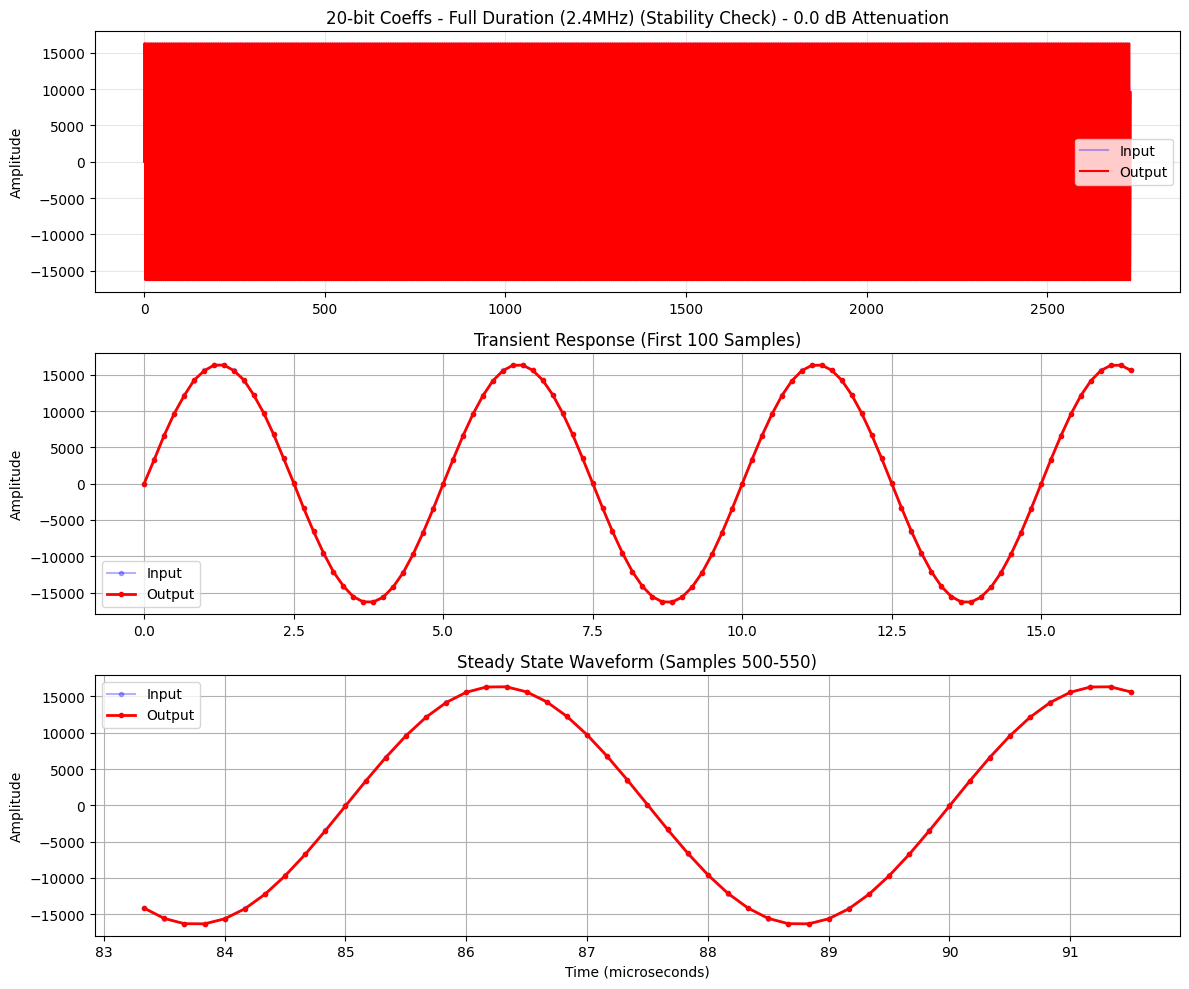

In [2]:
# Code to graph one frequency component to show the attenuation magnitude
import matplotlib.pyplot as plt
import numpy as np

# 1. Load data
try:
    input_sig = np.loadtxt("notch_stimulus.txt")
    output_sig = np.loadtxt("notch_expected_golden.txt")
except OSError:
    print("Error: Run the golden model script first to generate .txt files.")
    exit()

# 2. Setup
Fs = 6e6
time_axis = np.arange(len(input_sig)) / Fs * 1e6 

# 3. Calculate Stats
peak_in = np.max(np.abs(input_sig[-500:]))
peak_out = np.max(np.abs(output_sig[-500:]))
attenuation = 20 * np.log10(peak_out/peak_in) if peak_in > 0 else 0
print(f"Attenuation: {abs(attenuation):.2f} dB")

# 4. PLOTTING
plt.figure(figsize=(12, 10))

# GRAPH 1: The "Cloud" (Shows stability over long time)
plt.subplot(3, 1, 1)
plt.plot(time_axis, input_sig, color='blue', alpha=0.3, label='Input')
plt.plot(time_axis, output_sig, color='red', label='Output')
plt.title(f"20-bit Coeffs - Full Duration (2.4MHz) (Stability Check) - {abs(attenuation):.1f} dB Attenuation")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.3)

# GRAPH 2: The Transient (First 100 Samples)
# This shows the "kick" at the start
N_zoom = 100
plt.subplot(3, 1, 2)
plt.plot(time_axis[:N_zoom], input_sig[:N_zoom], 'b.-', alpha=0.3, label='Input')
plt.plot(time_axis[:N_zoom], output_sig[:N_zoom], 'r.-', linewidth=2, label='Output')
plt.title(f"Transient Response (First {N_zoom} Samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

# GRAPH 3: Steady State Zoom (Samples 500 to 550)
# This shows the wave shape clearly!
start = 500
end = 550
plt.subplot(3, 1, 3)
plt.plot(time_axis[start:end], input_sig[start:end], 'b.-', alpha=0.3, label='Input')
plt.plot(time_axis[start:end], output_sig[start:end], 'r.-', linewidth=2, label='Output')
plt.title(f"Steady State Waveform (Samples {start}-{end})")
plt.xlabel("Time (microseconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# 2.4 MHz Notch Filter 20 bit Coeffecients Golden Model
import numpy as np

# ======================================================
# 1. Settings
# ======================================================
Fs = 6e6
N  = 16384
stim_file = "notch_stimulus.txt"
exp_file  = "notch_expected_golden.txt"
INT16_MIN, INT16_MAX = -32768, 32767

# ======================================================
# 2. EXACT Coefficients Extracted from Your Verilog
# ======================================================

# --- INPUT GAIN (dsphdl_BiquadFilter.v) ---
# Code: assign sec0mul = 16'sb0111100110100000 * sec0reg;
# This is STILL Q1.15 (16-bit)
GAIN_IN = 31136     
GAIN_SHIFT = 15     

# --- FILTER COEFFICIENTS (BiquadDF2Section1.v) ---
# Code uses 20-bit signed multipliers (20'sb...)
# This implies Q2.18 format (18 fractional bits)
COEFF_SHIFT = 18


# 20-BIT COEFFICIENTS FOR EXACTLY 2.4 MHz ---

# Numerator
B0 = 262144        # 1.0
B1 = 424158        # <--- THE MAGIC NUMBER (Was 424740)
B2 = 262144        # 1.0

# Denominator (Adjusted to maintain stability with new frequency)
# Keep A2 the same (it controls bandwidth/radius)
A2 = -236036       
# Recalculate A1 based on new angle: A1 approx = -B1 * 0.9488
A1 = -402470       # (Was -403589)


# --- OUTPUT GAIN (dsphdl_BiquadFilter.v) ---
# Code: assign sec1mul = 16'sb0111111111111111 * sec1out;
# This is STILL Q1.15 (16-bit)
GAIN_OUT = 32767    
OUT_SHIFT = 15

# ======================================================
# 3. Accurate Math Functions
# ======================================================
def sat16(x):
    if x > INT16_MAX: return INT16_MAX
    if x < INT16_MIN: return INT16_MIN
    return int(x)

def round_convergent(val, shift_amount):
    # Hardware accurate rounding (Round to nearest)
    offset = 1 << (shift_amount - 1)
    rounded = val + offset
    return rounded >> shift_amount

# ======================================================
# 4. The Golden Model Logic
# ======================================================
def run_exact_model(input_signal_q15):
    output_signal = []
    
    # State Registers (High Precision Q33)
    # Input(Q15) * Coeff(Q18) = Q33
    state1 = 0
    state2 = 0
    
    for x_raw in input_signal_q15:
        x_in = int(x_raw)
        
        # 1. Input Gain (Q15 scaling)
        sec0_mult = x_in * GAIN_IN 
        sec0_out = sat16(round_convergent(sec0_mult, GAIN_SHIFT))
        
        # --- BIQUAD CORE ---
        
        # 2. B0 Path
        # Shift by 18 (COEFF_SHIFT) to align with Q33 state
        num_prod1 = sec0_out << COEFF_SHIFT 
        
        # Accumulate
        den_sum1 = num_prod1 + state1
        
        # 3. Quantize Output (Round Q33 -> Q15)
        den_out = sat16(round_convergent(den_sum1, COEFF_SHIFT))
        
        # 4. Update State 1
        num_prod2 = int(sec0_out) * int(B1) 
        den_prod1 = int(den_out) * int(A1)
        
        state1 = num_prod2 + state2 + den_prod1
        
        # 5. Update State 2
        num_prod3 = sec0_out << COEFF_SHIFT
        den_prod2 = int(den_out) * int(A2)
        
        state2 = num_prod3 + den_prod2
        
        # --- OUTPUT GAIN (Q15 scaling) ---
        sec1_mult = int(den_out) * int(GAIN_OUT)
        final_out = sat16(round_convergent(sec1_mult, OUT_SHIFT))
        
        output_signal.append(final_out)

    return np.array(output_signal, dtype=np.int16)

# ======================================================
# 5. Run & Generate Files
# ======================================================
# Stimulus: 2.4 MHz Sine Wave (Target Freq)
t = np.arange(N) / Fs
x_float = 0.5 * np.sin(2 * np.pi * 200e3 * t) + 0.1 * np.sin(2 * np.pi * 2.4e6 * t)
x_int = np.clip(np.round(x_float * 32768), INT16_MIN, INT16_MAX).astype(np.int16)

print(f"[INFO] Input range: {np.min(x_int)} to {np.max(x_int)}")

# Write Stimulus
with open(stim_file, "w") as f:
    for v in x_int:
        f.write(f"{int(v)}\n")
print(f"[SUCCESS] Generated {stim_file}")

# Run Model
y_out = run_exact_model(x_int)

print(f"[INFO] Output range: {np.min(y_out)} to {np.max(y_out)}")
print(f"[INFO] First 5 outputs: {y_out[:5]}")

# Write Expected Output
with open(exp_file, "w") as f:
    for v in y_out:
        f.write(f"{int(v)}\n")

print(f"[SUCCESS] Generated {exp_file} with Mixed Precision (16-bit Gains, 20-bit Coeffs).")

[INFO] Input range: -19411 to 19411
[SUCCESS] Generated notch_stimulus.txt
[INFO] Output range: -17270 to 18388
[INFO] First 5 outputs: [    0  5066  3790 12252 10486]
[SUCCESS] Generated notch_expected_golden.txt with Mixed Precision (16-bit Gains, 20-bit Coeffs).


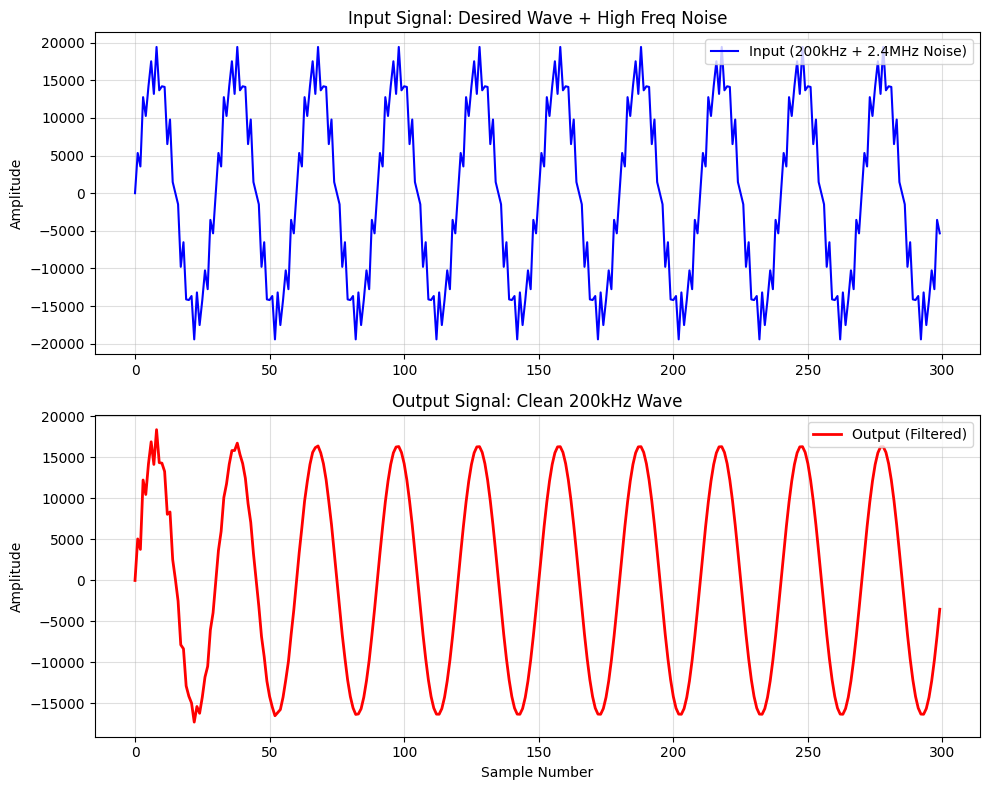

In [ ]:
#code to graph just input and output in two graphs

import matplotlib.pyplot as plt
import numpy as np

# 1. Load the files
try:
    input_sig = np.loadtxt("notch_stimulus.txt")
    output_sig = np.loadtxt("notch_expected_golden.txt")
except OSError:
    print("Error: Files not found. Run the Golden Model script first.")
    exit()

# 2. Settings for plotting
# We zoom in on the first 300 samples to see the wave shape clearly
# (300 samples = 50 microseconds)
samples_to_plot = 300
t = np.arange(samples_to_plot)

plt.figure(figsize=(10, 8))

# --- Graph 1: Input (Noisy) ---
plt.subplot(2, 1, 1)
plt.plot(t, input_sig[:samples_to_plot], color='blue', label='Input (200kHz + 2.4MHz Noise)')
plt.title("Input Signal: Desired Wave + High Freq Noise")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.4)
plt.legend(loc='upper right')

# --- Graph 2: Output (Clean) ---
plt.subplot(2, 1, 2)
plt.plot(t, output_sig[:samples_to_plot], color='red', linewidth=2, label='Output (Filtered)')
plt.title("Output Signal: Clean 200kHz Wave")
plt.xlabel("Sample Number")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.4)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [2]:
import numpy as np

# ======================================================
# Load RTL and golden model outputs
# ======================================================
rtl_file   = "tb_out_final.txt"
golden_file = "notch_expected_golden.txt"

rtl_out   = np.loadtxt(rtl_file, dtype=np.int16)
golden_out = np.loadtxt(golden_file, dtype=np.int16)

# Ensure same length
N = min(len(rtl_out), len(golden_out))
rtl_out   = rtl_out[:N]
golden_out = golden_out[:N]

# ======================================================
# RMS calculations
# ======================================================
def rms(signal):
    return np.sqrt(np.mean(signal.astype(np.int64)**2))

rms_rtl    = rms(rtl_out)
rms_golden = rms(golden_out)

# RMS error (difference signal)
diff       = rtl_out.astype(np.int64) - golden_out.astype(np.int64)
rms_error  = rms(diff)

# Normalized error (relative to golden RMS)
norm_error = rms_error / rms_golden if rms_golden > 0 else float('nan')

print("=== RMS Comparison ===")
print(f"Golden RMS   = {rms_golden:.2f}")
print(f"RTL RMS      = {rms_rtl:.2f}")
print(f"RMS Error    = {rms_error:.2f}")
print(f"Relative Err = {norm_error*100:.4f}%")

=== RMS Comparison ===
Golden RMS   = 11591.52
RTL RMS      = 11591.52
RMS Error    = 0.00
Relative Err = 0.0000%
